In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("../dataset/toyona_gold_synthetic_ctgan.csv")
df.head()

,возраст,пол,семейное положение,количество иждивенцев,профессия,статус клиента,зарплата,сумма кредита,ежемесячное погашение по графику,активные кредиты,первоначальный взнос,наличие карты,филиал,название продукта,is_bad_client
0,21.0,female,женат,NaN,tikuvchi,активный,3475426.0,16585503,972610,0,25397,да,turkiston,кулон,1
1,74.0,female,замужем,1.0,nonvoy,активный,5132046.0,7117917,509896,1,18494,нет,turkiston,кулон,0
2,75.0,female,замужем,3.0,xususiy amaliyod,активный,10075339.0,6954539,314142,1,0,да,navoiy,кулон,0
3,56.0,male,холост,1.0,tikuvchi,активный,6475233.0,14037579,753328,0,0,нет,turkiston,кольцо,0
4,75.0,female,холост,1.0,rais,активный,2548562.0,3233721,592693,2,0,нет,turkiston,кулон,0


In [3]:
df.dtypes

возраст                             float64
пол                                  object
семейное положение                   object
количество иждивенцев               float64
профессия                            object
статус клиента                       object
зарплата                            float64
сумма кредита                         int64
ежемесячное погашение по графику      int64
активные кредиты                      int64
первоначальный взнос                  int64
наличие карты                        object
филиал                               object
название продукта                    object
is_bad_client                         int64
dtype: object

In [4]:
df['is_bad_client'].value_counts()

0    6000
1    4000
Name: is_bad_client, dtype: int64

In [5]:
npl_ratio = df["is_bad_client"].mean() * 100
print(f"NPL: {npl_ratio:.2f}%")

NPL: 40.00%


In [6]:
df.isna().sum()

возраст                               83
пол                                    0
семейное положение                     0
количество иждивенцев               1340
профессия                            428
статус клиента                         0
зарплата                             202
сумма кредита                          0
ежемесячное погашение по графику       0
активные кредиты                       0
первоначальный взнос                   0
наличие карты                          0
филиал                                 0
название продукта                      0
is_bad_client                          0
dtype: int64

In [7]:
feature_cols = [
    'возраст', 'пол', 'семейное положение', 'количество иждивенцев',
    'профессия', 'статус клиента', 'зарплата', 'сумма кредита',
    'ежемесячное погашение по графику', 'активные кредиты',
    'первоначальный взнос', 'наличие карты', 'филиал', 'название продукта'
]

In [8]:
target_col = 'is_bad_client'

In [9]:
categorical_cols = [
    'пол', 'семейное положение', 'профессия',
    'статус клиента', 'наличие карты', 'филиал', 'название продукта'
]

In [16]:
y = df["is_bad_client"]
X = df.drop(columns=["is_bad_client"])

In [ ]:
#Preprocessing for numeric ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())                 
])


In [ ]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("onehot", OneHotEncoder(handle_unknown="ignore")) 
])


In [13]:
numeric_cols = list(set(feature_cols) - set(categorical_cols))
numeric_cols

['первоначальный взнос',
 'возраст',
 'количество иждивенцев',
 'ежемесячное погашение по графику',
 'сумма кредита',
 'активные кредиты',
 'зарплата']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [ ]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200, 
        random_state=42,
        class_weight="balanced"
    ))
])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['первоначальный взнос',
                                                   'возраст',
                                                   'количество иждивенцев',
                                                   'ежемесячное погашение по '
                                                   'графику',
                                                   'сумма кредита',
                                                   'активные кредиты',
                                                   'зарплата']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['пол', 'семейное положение',
                                                   'профессия',
                                                   'статус клиента',
                                                   'наличие карты', 'филиал',
                                                   'название продукта'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [ ]:
print("Train accuracy:", clf.score(X_train, y_train))
print("Test accuracy:", clf.score(X_test, y_test))

Train accuracy: 0.999875
Test accuracy: 0.836


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 500],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2", None]
}

In [21]:
grid_search = GridSearchCV(
    clf, param_grid, cv=3, scoring="f1", n_jobs=-1, verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   1.0s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.9s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=200; total time=   1.3s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=2, classifier__n_estimators=200; total time=   1.4s
[CV] END classifier__max_depth=5, classifier__max_features=sqrt, classifier__min_samples_split=5, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=5, classifier__max_featu

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['первоначальный '
                                                                          'взнос',
                                                                          'возраст',
                                                                          'количество '
                                                                          'иждивенцев',
                                                                          'ежемесячное '
                                                                          'погашение '
                                                                          'по '
                                                                          'графику',
                                                                          'сумма '
                                                                          'кредита',
                                                                          'активные '
                                                                          'кредиты',
                                                                          'зарплата']),
                                                                        ('cat',
                                                                         Pipel...
                                                                          'карты',
                                                                          'филиал',
                                                                          'название '
                                                                          'продукта'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, 20, None],
                         'classifier__max_features': ['sqrt', 'log2', None],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 500]},
             scoring='f1', verbose=2)

In [22]:
print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best params: {'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 10, 'classifier__n_estimators': 500}
Best CV score: 0.7968398597262883


In [23]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1200
           1       0.81      0.77      0.79       800

    accuracy                           0.84      2000
   macro avg       0.83      0.82      0.83      2000
weighted avg       0.84      0.84      0.84      2000

[[1061  139]
 [ 188  612]]


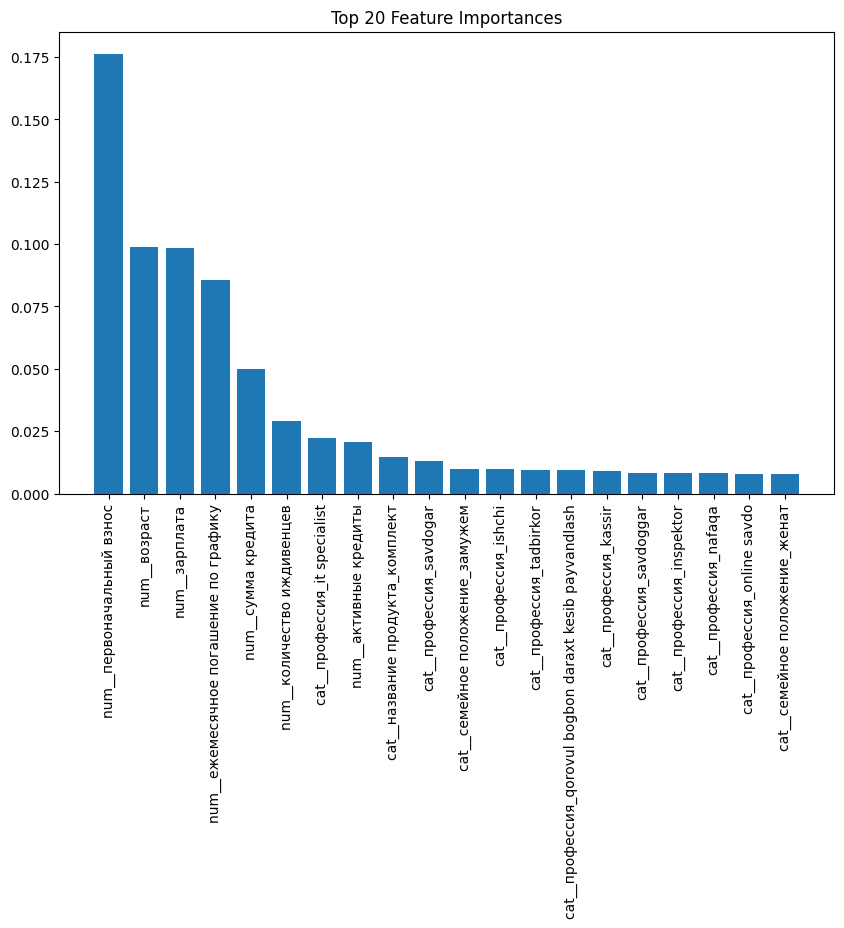

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


feature_names = grid_search.best_estimator_["preprocessor"].get_feature_names_out()
importances = grid_search.best_estimator_["classifier"].feature_importances_

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), feature_names[indices][:20], rotation=90)
plt.title("Top 20 Feature Importances")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, classification_report

def find_best_threshold_balanced(model, X_valid, y_valid, beta=1.0, grid_size=201, f1_tol=0.01,
                                 min_precision=None, min_recall=None):
 
    y_proba = model.predict_proba(X_valid)[:, 1]
    thresholds = np.linspace(0.0, 1.0, grid_size)

    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        prec = precision_score(y_valid, y_pred, zero_division=0) * 100
        rec  = recall_score(y_valid, y_pred, zero_division=0) * 100
        f1   = f1_score(y_valid, y_pred, zero_division=0) * 100
        fbet = fbeta_score(y_valid, y_pred, beta=beta, zero_division=0) * 100
        
        tn, fp, fn, tp = confusion_matrix(y_valid, y_pred).ravel()
        npl = (fn / (tp + fn) * 100) if (tp + fn) > 0 else np.nan
        acc = ((tp + tn) / (tp + tn + fp + fn)) * 100

        rows.append((t*100, prec, rec, f1, fbet, acc, abs(prec - rec), npl))

    metrics_df = pd.DataFrame(
        rows,
        columns=["threshold", "precision", "recall", "f1", "f_beta", "accuracy", "prec_recall_gap", "npl"]
    )

    cand = metrics_df.copy()
    if min_precision is not None:
        cand = cand[cand["precision"] >= min_precision * 100]
    if min_recall is not None:
        cand = cand[cand["recall"] >= min_recall * 100]
    if cand.empty:
        cand = metrics_df 


    max_f1 = cand["f1"].max() if beta == 1.0 else cand["f_beta"].max()
    score_col = "f1" if beta == 1.0 else "f_beta"

    near_opt = cand[cand[score_col] >= max_f1 * (1 - f1_tol)]

    best_row = near_opt.sort_values(
        ["prec_recall_gap", score_col, "threshold"],
        ascending=[True, False, True]
    ).iloc[0]
    best_threshold = float(best_row["threshold"])
    return best_threshold, metrics_df, best_row


In [ ]:
best_model = grid_search.best_estimator_

best_thr, metrics_table, best_metrics = find_best_threshold_balanced(
    best_model, X_test, y_test,
    beta=1.0,
    grid_size=401,
    f1_tol=0.01
)

print(f"Лучший порог: {best_thr:.3f}")
print("Метрики на лучшем пороге:")
print(best_metrics)

Лучший порог: 47.750
Метрики на лучшем пороге:
threshold          47.75
precision          79.25
recall             79.25
f1                 79.25
f_beta             79.25
accuracy           83.40
prec_recall_gap     0.00
npl                20.75
Name: 191, dtype: float64


In [48]:
best_thr = best_thr / 100 

In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba >= best_thr).astype(int)

print("\nClassification report @ optimal threshold:")
print(classification_report(y_test, y_pred_opt, digits=3))
print("Confusion matrix @ optimal threshold:")
print(confusion_matrix(y_test, y_pred_opt))

print("\nTop 10 порогов по F1 + баланс precision/recall + NPL:")
print(
    metrics_table.sort_values(["f1", "prec_recall_gap"], ascending=[False, True])
                 .head(10)
                 .round(3)
)



Classification report @ optimal threshold:
              precision    recall  f1-score   support

           0      0.862     0.862     0.862      1200
           1      0.792     0.792     0.792       800

    accuracy                          0.834      2000
   macro avg      0.827     0.827     0.827      2000
weighted avg      0.834     0.834     0.834      2000

Confusion matrix @ optimal threshold:
[[1034  166]
 [ 166  634]]

Top 10 порогов по F1 + баланс precision/recall + NPL:
     threshold  precision  recall      f1  f_beta  accuracy  prec_recall_gap  \
180      45.00     77.040  82.625  79.735  79.735     83.20            5.585   
179      44.75     76.674  83.000  79.712  79.712     83.10            6.326   
178      44.50     76.376  83.250  79.665  79.665     83.00            6.874   
177      44.25     76.142  83.375  79.594  79.594     82.90            7.233   
181      45.25     77.113  82.125  79.540  79.540     83.10            5.012   
183      45.75     77.553  81

In [50]:
metrics_table.to_csv("metrics_table.csv", index=False)

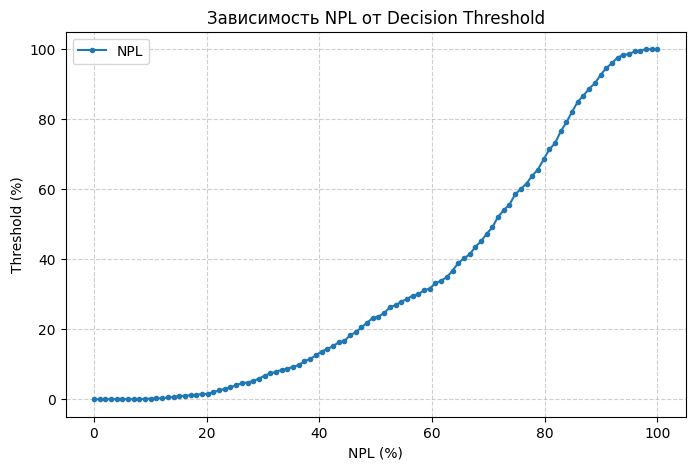

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def npl_at_thresholds(y_true, y_proba, thresholds):
    npl_scores = []
    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        # NPL = FN / (TP + FN)
        if (tp + fn) > 0:
            npl = fn / (tp + fn)
        else:
            npl = np.nan
        npl_scores.append(npl)
    return npl_scores


thresholds = np.linspace(0, 1, 100)
npl_values = npl_at_thresholds(y_test, y_proba, thresholds)

plt.figure(figsize=(8,5))
plt.plot(thresholds * 100, np.array(npl_values) * 100, marker="o", markersize=3, label="NPL")
plt.xlabel("NPL (%)")
plt.ylabel("Threshold (%)")
plt.title("Зависимость NPL от Decision Threshold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


In [60]:
import pickle
with open("../model/toyona_gold_rf_model.pkl", "wb") as f:
    pickle.dump(best_model, f)